## Linear Regression

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

path=r"C:\Users\indun\Downloads\Position_Salaries.csv"
dataset=pd.read_csv(path)
x=dataset.iloc[:,1:-1]
y=dataset.iloc[:,-1]
print("The dataset preview")
print(dataset.head())


The dataset preview
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [3]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg=PolynomialFeatures(degree=4)
x_poly=ploy_reg.fit_transform(x)
lin_reg_2=LinearRegression()
lin_reg_2.fit(x_poly,y)
print("Model Trained Succesfully")

Model Trained Succesfully


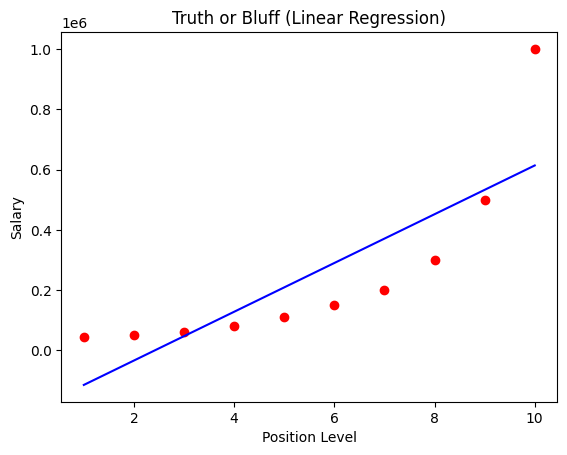

In [16]:
plt.scatter(x,y,color='red')
plt.plot(x,lin_reg.predict(x),color='blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()


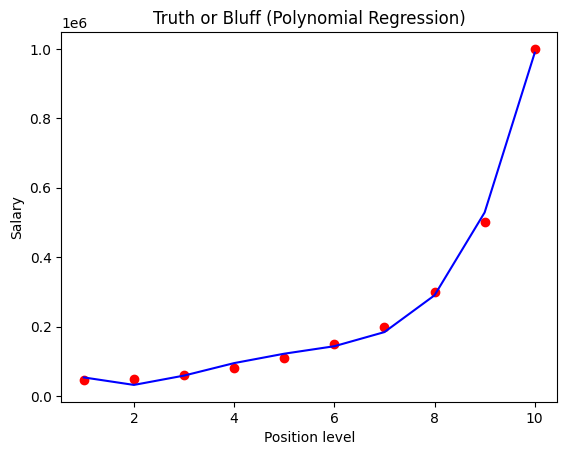

In [19]:
plt.scatter(x, y, color = 'red')
plt.plot(x, lin_reg_2.predict(poly_reg.fit_transform(x)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()


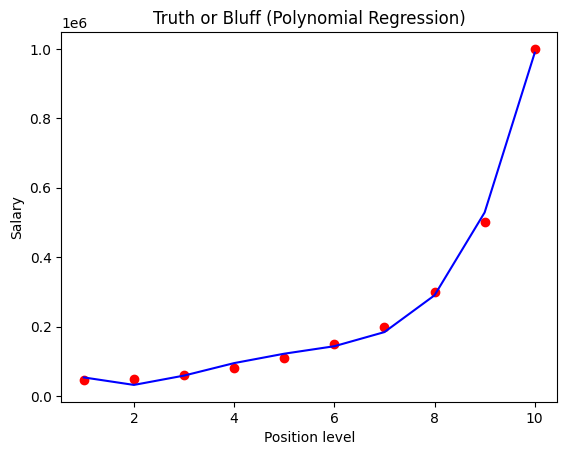

In [20]:
plt.scatter(x, y, color = 'red')
plt.plot(x, lin_reg_2.predict(poly_reg.fit_transform(x)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()


In [21]:
linear_prediction = lin_reg.predict([[6.5]])
print("Linear Regression Prediction for Level 6.5:", linear_prediction)


Linear Regression Prediction for Level 6.5: [330378.78787879]


c:\Users\indun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
poly_prediction = lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))
print("Polynomial Regression Prediction for Level 6.5:", poly_prediction)


Polynomial Regression Prediction for Level 6.5: [158862.45265155]


## Tasks
Load the dataset and identify the relevant columns.
Use:
Engine size as the input feature
Car price as the output variable
Visualize the relationship between engine size and price.
Build a predictive model to estimate car price based on engine size.
Predict the price for a car with:
Engine size = 200

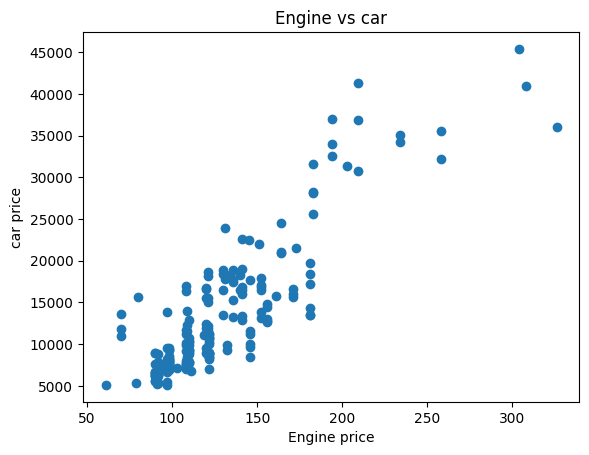

In [36]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

path=r"C:\Users\indun\Downloads\archive (7)\CarPrice_Assignment.csv"
dataset=pd.read_csv(path)
x=dataset[['enginesize']].values
y=dataset['price'].values

plt.scatter(x,y )
plt.xlabel("Engine price")
plt.ylabel("car price")
plt.title("Engine vs car")
plt.show()

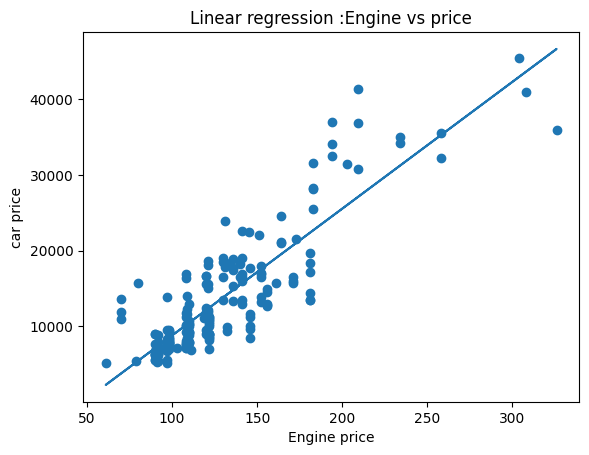

In [37]:
from sklearn.linear_model import LinearRegression
l=LinearRegression()
l.fit(x,y)
plt.scatter(x,y)
plt.plot(x,l.predict(x))
plt.xlabel("Engine price")
plt.ylabel("car price")
plt.title("Linear regression :Engine vs price")
plt.show()


In [38]:
predicted_price=l.predict([[200]])
print("predicted car price for engine size 200:",predicted_price[0])

predicted car price for engine size 200: 25534.23774748923


In [39]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Increase flexibility by using polynomial features
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(x)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


C:\Users\indun\AppData\Local\Temp\ipykernel_24704\1653610896.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(x), max(x), 0.1).reshape(-1, 1)


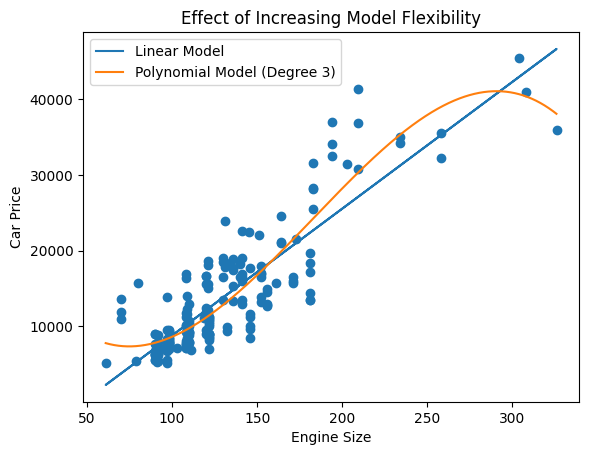

In [40]:
X_grid = np.arange(min(x), max(x), 0.1).reshape(-1, 1)

plt.scatter(x, y)
plt.plot(x, l.predict(x), label="Linear Model")
plt.plot(X_grid, poly_model.predict(poly.fit_transform(X_grid)),
         label="Polynomial Model (Degree 3)")
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Effect of Increasing Model Flexibility")
plt.legend()
plt.show()


In [41]:
engine_size = 200

linear_pred = l.predict([[engine_size]])
poly_pred = poly_model.predict(poly.fit_transform([[engine_size]]))

print("Linear Prediction:", linear_pred[0])
print("Polynomial Prediction:", poly_pred[0])


Linear Prediction: 25534.23774748923
Polynomial Prediction: 28207.451636708156


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Linear errors
lin_mae = mean_absolute_error(y, l.predict(x))
lin_rmse = np.sqrt(mean_squared_error(y, l.predict(x)))

# Polynomial errors
poly_mae = mean_absolute_error(y, poly_model.predict(X_poly))
poly_rmse = np.sqrt(mean_squared_error(y, poly_model.predict(X_poly)))

print("Linear MAE:", lin_mae)
print("Linear RMSE:", lin_rmse)
print("Polynomial MAE:", poly_mae)
print("Polynomial RMSE:", poly_rmse)


Linear MAE: 2815.0223538364103
Linear RMSE: 3870.4342657576967
Polynomial MAE: 2692.4289084528027
Polynomial RMSE: 3618.221247975695


In [50]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
print(l.score(x_train,y_train))

print(l.score(x_test,y_test))

0.750597282039292
0.8048496655399958


In [53]:
import seaborn as sns

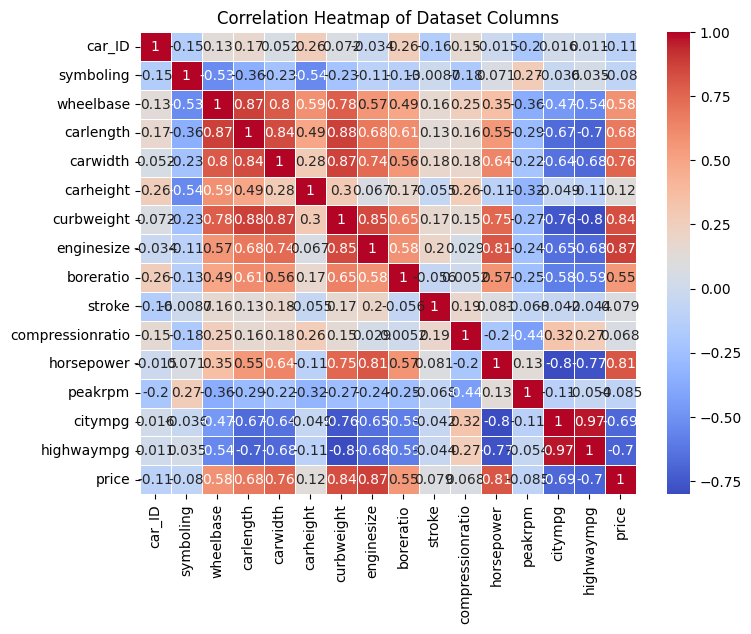

In [58]:
num_data=dataset.select_dtypes(include=['int64','float64'])
corr_matrix = num_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Dataset Columns")
plt.show()


## Engine_size vs Price -->High positive value(0.87)
Price have strong influence by engine size
## car height vs price --> have low positive value 
Doesn't have any impact
## wheelbase vs price -->(0.58)
Moderate positive impact
## Curb weight strongly affects price
Correlation = 0.84
## Indicates size & build quality matter
## Car dimensions influence price
Car length, width, wheelbase
Correlation with price =0.6 – 0.76
Bigger cars generally cost more
## Having the more engine size(0.87),horsepower(0.81),curbweight(0.84) impact the total price of cars.

## The features having less correlation values
-->citympg
-->highwaympg
-->symbolling

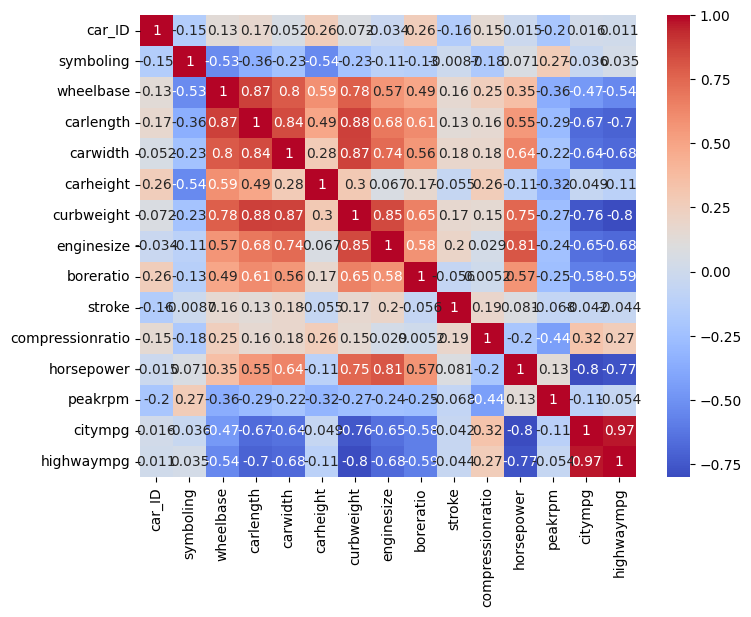

In [66]:
X=dataset.drop('price',axis=1)
 
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.show()

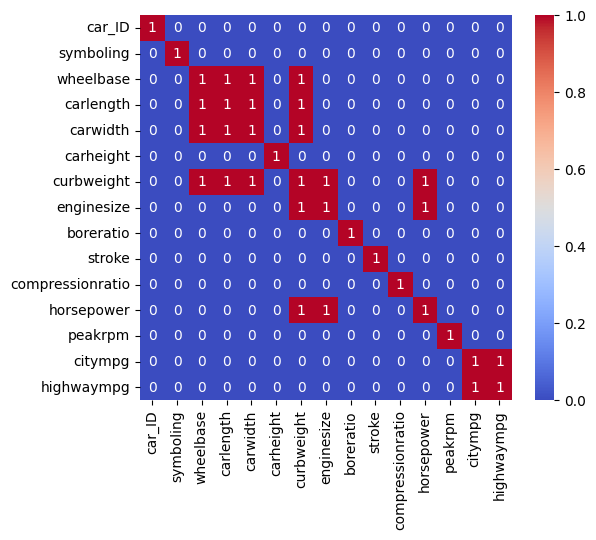

In [65]:
X=dataset.drop('price',axis=1)
 
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(X.corr(numeric_only=True)>0.75, annot=True,cmap='coolwarm')
plt.show()

for i in range x:


In [69]:
import pandas as pd
import numpy as np

# Select only numeric columns
numeric_data = dataset.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_data.corr()

corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) !=
                        corr_pairs.index.get_level_values(1)]
strong_corr = corr_pairs[abs(corr_pairs) > 0.75]

unique_corr = strong_corr.copy()
unique_corr.index = unique_corr.index.map(lambda x: tuple(sorted(x)))
unique_corr = unique_corr[~unique_corr.index.duplicated()]

for (feat1, feat2), value in unique_corr.items():
    print(f"{feat1}  <-->  {feat2}  :  {value:.2f}")



carlength  <-->  wheelbase  :  0.87
carwidth  <-->  wheelbase  :  0.80
curbweight  <-->  wheelbase  :  0.78
carlength  <-->  carwidth  :  0.84
carlength  <-->  curbweight  :  0.88
carwidth  <-->  curbweight  :  0.87
carwidth  <-->  price  :  0.76
curbweight  <-->  enginesize  :  0.85
curbweight  <-->  horsepower  :  0.75
citympg  <-->  curbweight  :  -0.76
curbweight  <-->  highwaympg  :  -0.80
curbweight  <-->  price  :  0.84
enginesize  <-->  horsepower  :  0.81
enginesize  <-->  price  :  0.87
citympg  <-->  horsepower  :  -0.80
highwaympg  <-->  horsepower  :  -0.77
horsepower  <-->  price  :  0.81
citympg  <-->  highwaympg  :  0.97


In [71]:
import pandas as pd
import numpy as np

# Select numeric columns
numeric_data = dataset.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()
target = 'price'

feature_target_corr = corr_matrix[target].drop(target)

strong_ft = feature_target_corr[abs(feature_target_corr) > 0.75]
print("Feature  <-->  Target (price)\n")

for feature, value in strong_ft.items():
    print(f"{feature}  <-->  price  :  {value:.2f}")



Feature  <-->  Target (price)

carwidth  <-->  price  :  0.76
curbweight  <-->  price  :  0.84
enginesize  <-->  price  :  0.87
horsepower  <-->  price  :  0.81


In [72]:
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0) !=
    corr_pairs.index.get_level_values(1)
]
strong_pairs = corr_pairs[abs(corr_pairs) > 0.75]

unique_pairs = strong_pairs.copy()
unique_pairs.index = unique_pairs.index.map(lambda x: tuple(sorted(x)))
unique_pairs = unique_pairs[~unique_pairs.index.duplicated()]
unique_pairs = unique_pairs[
    (unique_pairs.index.get_level_values(0) != target) &
    (unique_pairs.index.get_level_values(1) != target)
]
print("\nFeature  <-->  Feature (Unique Pairs)\n")

for (f1, f2), value in unique_pairs.items():
    print(f"{f1}  <-->  {f2}  :  {value:.2f}")



Feature  <-->  Feature (Unique Pairs)

carlength  <-->  wheelbase  :  0.87
carwidth  <-->  wheelbase  :  0.80
curbweight  <-->  wheelbase  :  0.78
carlength  <-->  carwidth  :  0.84
carlength  <-->  curbweight  :  0.88
carwidth  <-->  curbweight  :  0.87
curbweight  <-->  enginesize  :  0.85
curbweight  <-->  horsepower  :  0.75
citympg  <-->  curbweight  :  -0.76
curbweight  <-->  highwaympg  :  -0.80
enginesize  <-->  horsepower  :  0.81
citympg  <-->  horsepower  :  -0.80
highwaympg  <-->  horsepower  :  -0.77
citympg  <-->  highwaympg  :  0.97


In [74]:
import pandas as pd
import numpy as np

corr = dataset.corr(numeric_only=True)

target = 'price'

feature_target = corr[target].drop(target)

ft_df = feature_target.abs().reset_index()
ft_df.columns = ['Feature', 'Correlation']

def strength(val):
    if val >= 0.75:
        return 'Strong'
    elif val >= 0.40:
        return 'Moderate'
    else:
        return 'Weak'

ft_df['Strength'] = ft_df['Correlation'].apply(strength)

print("Feature - Target Correlation")
print(ft_df.sort_values(by='Correlation', ascending=False))


Feature - Target Correlation
             Feature  Correlation  Strength
7         enginesize     0.874145    Strong
6         curbweight     0.835305    Strong
11        horsepower     0.808139    Strong
4           carwidth     0.759325    Strong
14        highwaympg     0.697599  Moderate
13           citympg     0.685751  Moderate
3          carlength     0.682920  Moderate
2          wheelbase     0.577816  Moderate
8          boreratio     0.553173  Moderate
5          carheight     0.119336      Weak
0             car_ID     0.109093      Weak
12           peakrpm     0.085267      Weak
1          symboling     0.079978      Weak
9             stroke     0.079443      Weak
10  compressionratio     0.067984      Weak


In [75]:
pairs = []

cols = corr.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):   # ensures unique pairs
        corr_val = corr.iloc[i, j]
        pairs.append({
            'Feature_1': cols[i],
            'Feature_2': cols[j],
            'Correlation': abs(corr_val),
            'Strength': strength(abs(corr_val))
        })

ff_df = pd.DataFrame(pairs)

print("Feature - Feature Pairs")
print(ff_df.sort_values(by='Correlation', ascending=False))


Feature - Feature Pairs
      Feature_1         Feature_2  Correlation Strength
117     citympg        highwaympg     0.971337   Strong
44    carlength        curbweight     0.877728   Strong
29    wheelbase         carlength     0.874587   Strong
91   enginesize             price     0.874145   Strong
55     carwidth        curbweight     0.867032   Strong
..          ...               ...          ...      ...
12       car_ID           citympg     0.015940     Weak
10       car_ID        horsepower     0.015006     Weak
13       car_ID        highwaympg     0.011255     Weak
22    symboling            stroke     0.008735     Weak
93    boreratio  compressionratio     0.005197     Weak

[120 rows x 4 columns]


In [76]:
strong_pairs = ff_df[ff_df['Strength'] == 'Strong']
moderate_pairs = ff_df[ff_df['Strength'] == 'Moderate']
weak_pairs = ff_df[ff_df['Strength'] == 'Weak']

print("Strong Feature Pairs:\n", strong_pairs)
print("Moderate Feature Pairs:\n", moderate_pairs)
print("Weak Feature Pairs:\n", weak_pairs)


Strong Feature Pairs:
       Feature_1   Feature_2  Correlation Strength
29    wheelbase   carlength     0.874587   Strong
30    wheelbase    carwidth     0.795144   Strong
32    wheelbase  curbweight     0.776386   Strong
42    carlength    carwidth     0.841118   Strong
44    carlength  curbweight     0.877728   Strong
55     carwidth  curbweight     0.867032   Strong
64     carwidth       price     0.759325   Strong
75   curbweight  enginesize     0.850594   Strong
79   curbweight  horsepower     0.750739   Strong
81   curbweight     citympg     0.757414   Strong
82   curbweight  highwaympg     0.797465   Strong
83   curbweight       price     0.835305   Strong
87   enginesize  horsepower     0.809769   Strong
91   enginesize       price     0.874145   Strong
111  horsepower     citympg     0.801456   Strong
112  horsepower  highwaympg     0.770544   Strong
113  horsepower       price     0.808139   Strong
117     citympg  highwaympg     0.971337   Strong
Moderate Feature Pairs:
   

In [ ]:
drop_col=['carlength','carwidth','curbweight','horsepower','highwaympg','carheight',]

In [77]:
# Correlation with target
corr_target = dataset.corr(numeric_only=True)['price']

# Find weak features
weak_features = corr_target[abs(corr_target) < 0.4].index.tolist()

# Remove target itself if present
weak_features.remove('price')

print("Weak (low-impact) features based on heatmap:")
print(weak_features)


ValueError: list.remove(x): x not in list

In [78]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error
lasso=Lasso(alpha=0.1)
lasso.fit(x_train,y_train)
y_pred=lasso.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 15465460.922668837


In [89]:
from sklearn.linear_model import RidgeCV
alphas=np.arange(0.1,10,0.05)
model=RidgeCV(alphas=alphas)

 
model.fit(x_train, y_train)
print("Best alpha selected:", model.alpha_)
print("best score: ",model.score(x_test,y_test))
 

Best alpha selected: 9.950000000000003
best score:  0.8040933847321597


In [90]:
from sklearn.linear_model import LassoCV
alphas=np.arange(0.1,10,0.05)
model=LassoCV(alphas=alphas)

 
model.fit(x_train, y_train)
print("Best alpha selected:", model.alpha_)
print("best score: ",model.score(x_test,y_test))

Best alpha selected: 9.950000000000003
best score:  0.8040934124003777
